**# Part 3 — NLP and Sequence Modeling Mini Project**


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, os, warnings
warnings.filterwarnings('ignore')
from collections import Counter

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, GRU, Dense, Dropout,
    Bidirectional, GlobalMaxPooling1D, SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
os.makedirs('results', exist_ok=True)

print(f'TensorFlow : {tf.__version__}')
print('Setup complete. Output folder: results/')


TensorFlow : 2.20.0
Setup complete. Output folder: results/


## Task 1 — Dataset Understanding

In [3]:
df = pd.read_csv('customer_support_text_classification.csv')
print('=' * 55)
print('  DATASET OVERVIEW')
print('=' * 55)
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')
print(f'  Columns : {df.columns.tolist()}')
print('=' * 55)
df.head(8)


  DATASET OVERVIEW
  Rows    : 1,500
  Columns : 6
  Columns : ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0
5,TKT00006,social,I need help finding the invoice for my last or...,neutral,16,1
6,TKT00007,chat,I am satisfied with the plan and would recomme...,positive,17,0
7,TKT00008,chat,I want to understand the warranty terms for th...,neutral,10,0


In [7]:
# Target labels / class distribution
print('=== Target Label: sentiment_label ===')

label_counts = df['sentiment_label'].value_counts()
print(label_counts)

print(f'\nClasses        : {sorted(df["sentiment_label"].unique())}')
print(f'Total records  : {len(df):,}')
print(f'Missing labels : {df["sentiment_label"].isnull().sum()}')

=== Target Label: sentiment_label ===
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Classes        : ['negative', 'neutral', 'positive']
Total records  : 1,500
Missing labels : 0


In [8]:
# Sample text records
pd.set_option('display.max_colwidth', 110)
print('=== Sample Records ===')
print(df[['customer_message', 'sentiment_label', 'urgent_flag']].sample(8, random_state=SEED).to_string(index=False))


=== Sample Records ===
                                                                           customer_message sentiment_label  urgent_flag
                                 I am checking if there is any scheduled maintenance today.         neutral            0
                The app experience is smooth and reliable. I appreciate the quick response.        positive            0
                                       Can you confirm whether my ticket has been assigned?         neutral            0
I have raised multiple tickets but nobody has fixed the problem. My ticket number is 88027.        negative            1
                                   Billing is incorrect and I was charged twice this month.        negative            1
                       I want to cancel because the service quality is poor and unreliable.        negative            0
                               The internet speed is slow and customer care is not helping.        negative            1
         

In [9]:
# Text length analysis
df['char_count'] = df['customer_message'].str.len()
df['word_count_calc'] = df['customer_message'].str.split().str.len()

print('=== Text Length Statistics ===')
stats = df.groupby('sentiment_label')[['char_count','word_count_calc']].describe().round(1)
print(stats.to_string())
print(f'\nOverall avg words per message : {df["word_count_calc"].mean():.1f}')
print(f'Overall avg chars per message : {df["char_count"].mean():.1f}')
print(f'Max word count                : {df["word_count_calc"].max()}')
print(f'Min word count                : {df["word_count_calc"].min()}')


=== Text Length Statistics ===
                char_count                                            word_count_calc                                        
                     count  mean   std   min   25%   50%   75%    max           count  mean  std  min   25%   50%   75%   max
sentiment_label                                                                                                              
negative             497.0  77.9  21.6  44.0  60.0  71.0  92.0  143.0           497.0  13.8  3.8  9.0  10.0  14.0  16.0  26.0
neutral              524.0  67.5  19.6  43.0  50.0  58.0  81.0  121.0           524.0  11.9  3.5  7.0   9.0  10.0  15.0  21.0
positive             479.0  73.1  20.7  42.0  60.0  70.0  88.0  130.0           479.0  12.5  3.5  7.0  10.0  12.0  15.0  23.0

Overall avg words per message : 12.7
Overall avg chars per message : 72.8
Max word count                : 26
Min word count                : 7


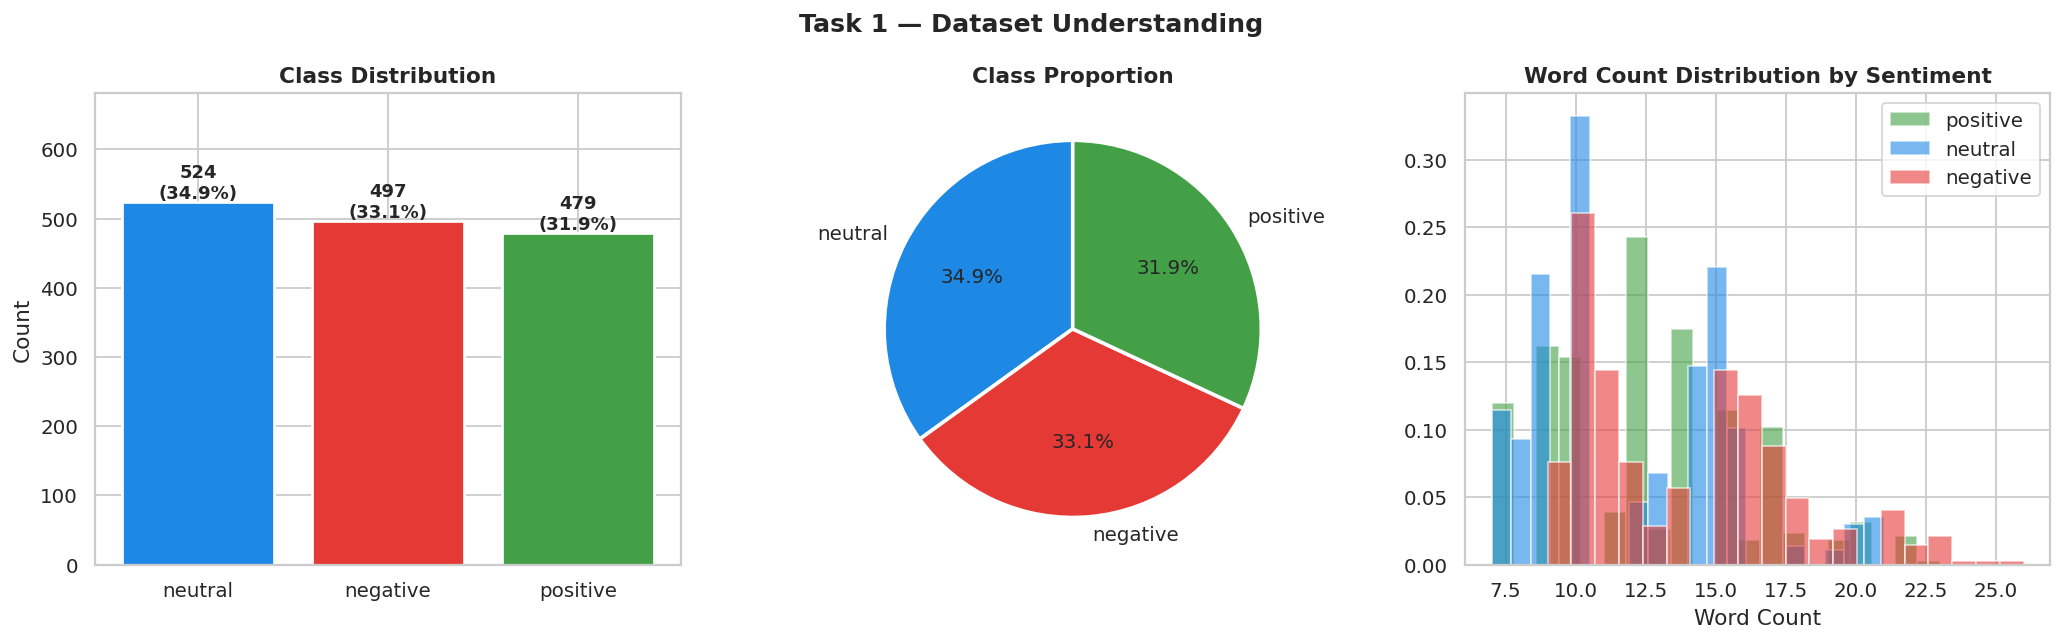

 Saved → results/task1_eda.png


In [10]:
# Task 1 visualisation
SENT_COLORS = {'positive':'#43A047','neutral':'#1E88E5','negative':'#E53935'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Task 1 — Dataset Understanding', fontsize=14, fontweight='bold')

# Class distribution bar
bars = axes[0].bar(label_counts.index, label_counts.values,
                   color=[SENT_COLORS[l] for l in label_counts.index],
                   edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, label_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+5,
                 f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].set_ylim(0, label_counts.max()*1.3)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=[SENT_COLORS[l] for l in label_counts.index],
            wedgeprops={'edgecolor':'white','linewidth':2}, startangle=90)
axes[1].set_title('Class Proportion', fontweight='bold')

# Word count distribution by sentiment
for lbl, color in SENT_COLORS.items():
    df[df['sentiment_label']==lbl]['word_count_calc'].hist(
        ax=axes[2], bins=20, alpha=0.6, label=lbl, color=color, density=True)
axes[2].set_xlabel('Word Count')
axes[2].set_title('Word Count Distribution by Sentiment', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('results/task1_eda.png', bbox_inches='tight')
plt.show()
print(' Saved → results/task1_eda.png')


## Task 2 — Text Preprocessing

In [11]:
# Stopwords list
STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you',"you're","you've",
    "you'll","you'd",'your','yours','yourself','yourselves','he','him','his',
    'himself','she',"she's",'her','hers','herself','it',"it's",'its','itself',
    'they','them','their','theirs','themselves','what','which','who','whom',
    'this','that',"that'll",'these','those','am','is','are','was','were','be',
    'been','being','have','has','had','having','do','does','did','doing','a',
    'an','the','and','but','if','or','because','as','until','while','of','at',
    'by','for','with','about','against','between','into','through','during',
    'before','after','above','below','to','from','up','down','in','out','on',
    'off','over','under','again','further','then','once','here','there','when',
    'where','why','how','all','both','each','few','more','most','other','some',
    'such','no','nor','not','only','own','same','so','than','too','very','s',
    't','can','will','just','don',"don't",'should',"should've",'now','d','ll',
    'm','o','re','ve','y','ain','aren',"aren't",'couldn',"couldn't",'didn',
    "didn't",'doesn',"doesn't",'hadn',"hadn't",'hasn',"hasn't",'haven',
    "haven't",'isn',"isn't",'ma','mightn',"mightn't",'mustn',"mustn't",
    'needn',"needn't",'shan',"shan't",'shouldn',"shouldn't",'wasn',"wasn't",
    'weren',"weren't",'won',"won't",'wouldn',"wouldn't"
}

def preprocess_text(text):
    """
    Full text preprocessing pipeline:
    1. Lowercase
    2. Remove URLs, ticket numbers, special characters
    3. Remove punctuation
    4. Remove digits
    5. Tokenize (split on whitespace)
    6. Remove stopwords
    7. Remove very short tokens
    """
    if not isinstance(text, str):
        return ''
    # Step 1: Lowercase
    text = text.lower()
    # Step 2: Remove URLs and email addresses
    text = re.sub(r'http\S+|www\S+|\S+@\S+', '', text)
    # Step 3: Remove ticket/reference numbers
    text = re.sub(r'ticket\s*(?:number|#|no\.?)\s*\d+', '', text)
    # Step 4: Remove digits
    text = re.sub(r'\d+', '', text)
    # Step 5: Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Step 6: Tokenize
    tokens = text.split()
    # Step 7: Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['customer_message'].apply(preprocess_text)

print('=== Preprocessing Examples ===')
for i in range(4):
    print(f'\nOriginal : {df["customer_message"].iloc[i][:90]}')
    print(f'Cleaned  : {df["clean_text"].iloc[i][:90]}')


=== Preprocessing Examples ===

Original : I need information about the payment process. My ticket number is 78732. Please respond as
Cleaned  : need information payment process ticket number please respond soon possible

Original : I need information about the payment process.
Cleaned  : need information payment process

Original : The refund process was fast and convenient. I appreciate the quick response.
Cleaned  : refund process fast convenient appreciate quick response

Original : My refund is still pending and this experience is frustrating. My ticket number is 33927.
Cleaned  : refund still pending experience frustrating ticket number


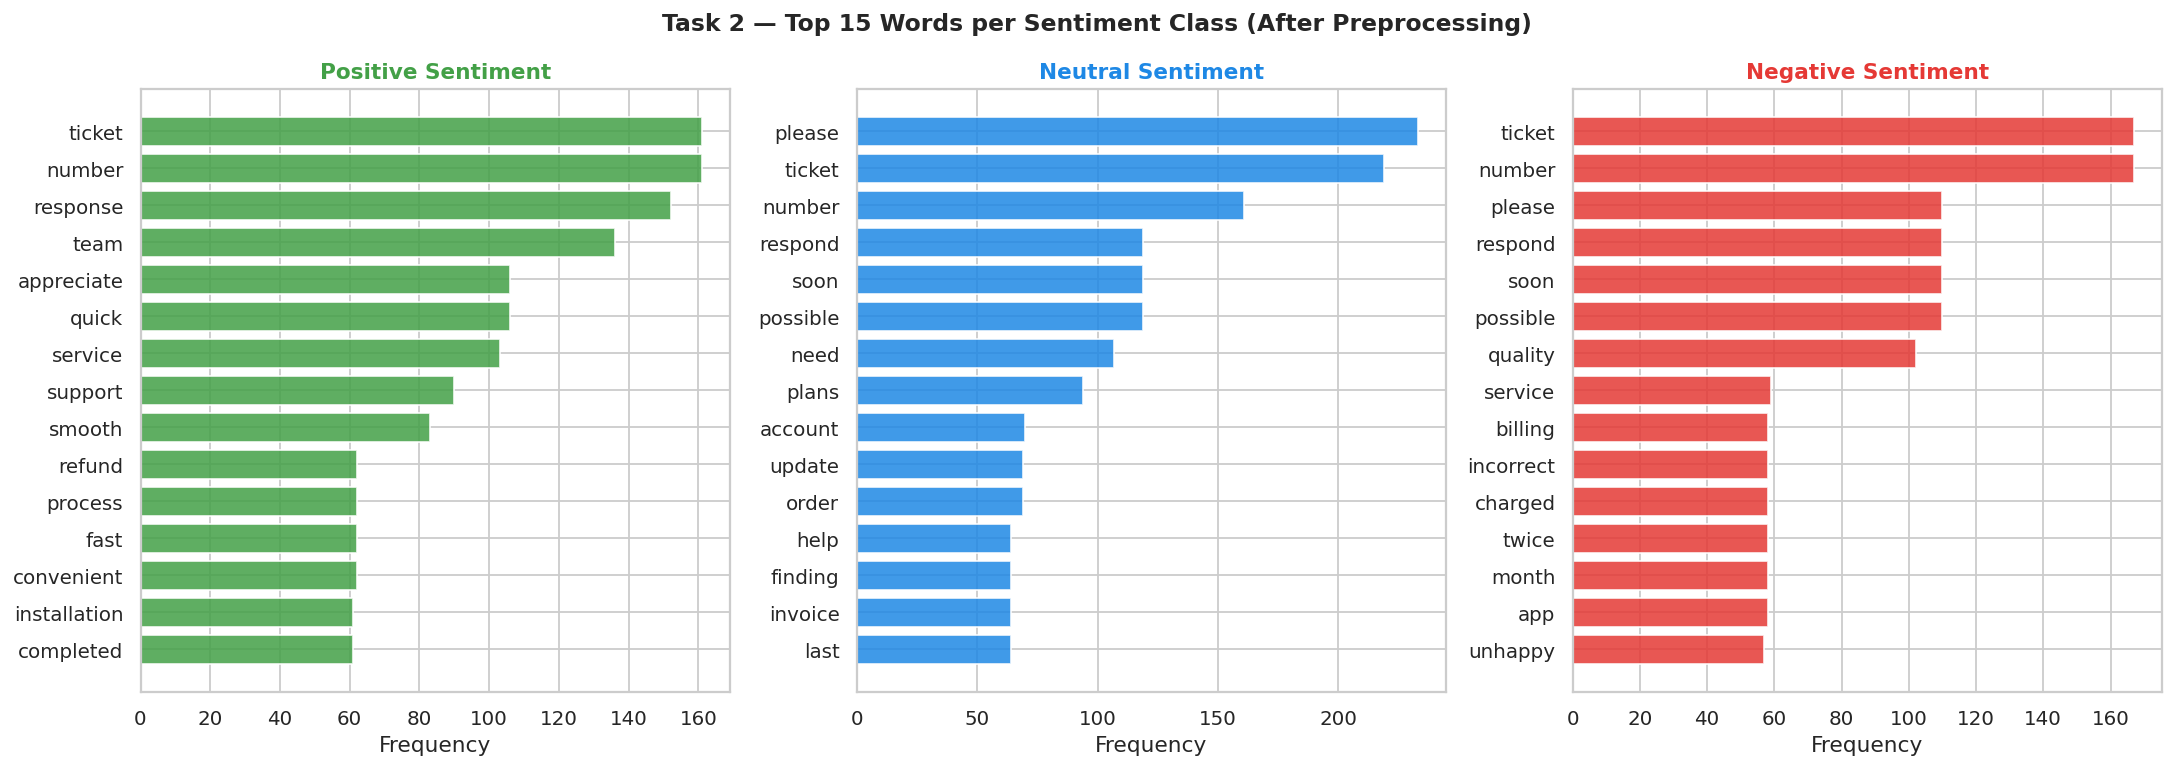

✅ Saved → results/task2_top_words.png


In [12]:
# Top words per class (before/after cleaning)
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Task 2 — Top 15 Words per Sentiment Class (After Preprocessing)',
             fontsize=13, fontweight='bold')

for ax, sentiment in zip(axes, ['positive','neutral','negative']):
    words = ' '.join(df[df['sentiment_label']==sentiment]['clean_text']).split()
    top15 = Counter(words).most_common(15)
    if top15:
        wds, cnts = zip(*top15)
        ax.barh(list(wds)[::-1], list(cnts)[::-1],
                color=SENT_COLORS[sentiment], alpha=0.85, edgecolor='white')
    ax.set_title(f'{sentiment.title()} Sentiment', fontweight='bold', color=SENT_COLORS[sentiment])
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('results/task2_top_words.png', bbox_inches='tight')
plt.show()
print('✅ Saved → results/task2_top_words.png')


## Task 3 — Text Vectorization

**Why must text be converted to vectors?**

Machine learning models perform mathematical operations (matrix multiplications, dot products) on **numbers**. Raw text strings cannot be multiplied or compared numerically. Vectorization maps each text to a fixed-length numerical representation so models can process it.

***Approaches used in this project:***

| Method | Type | Captures Order? | Captures Semantics? | Use |
|---|---|---|---|---|
| **Bag of Words** | Sparse count matrix | ❌ | ❌ | Simple baseline |
| **TF-IDF** | Sparse weighted matrix | ❌ | Partially | Strong baseline |
| **Tokenizer sequences** | Integer ID sequences | ✅ | Via embeddings | Deep learning |
| **Embedding layer** | Dense vectors (learned) | ✅ | ✅ | LSTM input |

In [45]:
# Label encoding
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['sentiment_label'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
N_CLASSES = len(le.classes_)

# Train / test split
X_raw = df['clean_text'].values
y     = df['label_enc'].values

X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'\nTrain: {len(X_tr_raw)} | Test: {len(X_te_raw)}')
print(f'Train class distribution: {dict(zip(*np.unique(y_tr, return_counts=True)))}')


Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

Train: 1200 | Test: 300
Train class distribution: {np.int64(0): np.int64(398), np.int64(1): np.int64(419), np.int64(2): np.int64(383)}


In [46]:
# Vectorisation 1: TF-IDF
tfidf = TfidfVectorizer(max_features=6000, ngram_range=(1, 2), sublinear_tf=True)
X_tr_tfidf = tfidf.fit_transform(X_tr_raw)   # fit only on train
X_te_tfidf = tfidf.transform(X_te_raw)

print(f'TF-IDF matrix shape  : {X_tr_tfidf.shape}  (samples × features)')
print(f'Sparsity             : {1 - X_tr_tfidf.nnz / (X_tr_tfidf.shape[0]*X_tr_tfidf.shape[1]):.4%}')
print(f'Top features (sample): {list(tfidf.get_feature_names_out()[:20])}')


TF-IDF matrix shape  : (1200, 429)  (samples × features)
Sparsity             : 97.1255%
Top features (sample): ['account', 'account details', 'account keeps', 'account request', 'account worked', 'account working', 'activate', 'activate analytics', 'activate login', 'activate notifications', 'activate payment', 'activate profile', 'activate report', 'activate tracking', 'activate video', 'ago', 'ago please', 'ago ticket', 'analytics', 'analytics easy']


In [47]:
# Vectorisation 2: Tokenizer sequences (for LSTM)
VOCAB_SIZE = 8000
MAX_LEN    = 50     # pad / truncate all sequences to 50 tokens
EMBED_DIM  = 64     # embedding vector size

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_tr_raw)           # fit ONLY on training data

X_tr_seq = tokenizer.texts_to_sequences(X_tr_raw)
X_te_seq = tokenizer.texts_to_sequences(X_te_raw)

# Padding: post-pad with zeros to MAX_LEN
X_tr_pad = pad_sequences(X_tr_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_te_pad = pad_sequences(X_te_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Vocabulary size (unique tokens) : {len(tokenizer.word_index):,}')
print(f'Tokens used (capped at)         : {VOCAB_SIZE:,}')
print(f'Padded sequence shape (train)   : {X_tr_pad.shape}  ← (samples × MAX_LEN)')
print(f'\nExample raw    : {X_tr_raw[0][:60]}')
print(f'Example encoded: {X_tr_pad[0]}')


Vocabulary size (unique tokens) : 148
Tokens used (capped at)         : 8,000
Padded sequence shape (train)   : (1200, 50)  ← (samples × MAX_LEN)

Example raw    : confirm whether ticket assigned please respond soon possible
Example encoded: [65 66  2 67  4  5  6  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0]


## Task 4 — Baseline Model

In [48]:
# Model A: Logistic Regression + TF-IDF
lr_clf = LogisticRegression(max_iter=1000, random_state=SEED, C=2.0, solver='lbfgs')
lr_clf.fit(X_tr_tfidf, y_tr)
y_pred_lr  = lr_clf.predict(X_te_tfidf)
acc_lr     = accuracy_score(y_te, y_pred_lr)
f1_lr      = f1_score(y_te, y_pred_lr, average='macro')

print('=== Baseline A: TF-IDF + Logistic Regression ===')
print(f'  Test Accuracy : {acc_lr:.4f}')


=== Baseline A: TF-IDF + Logistic Regression ===
  Test Accuracy : 1.0000


In [49]:
print(f'  Macro F1      : {f1_lr:.4f}')
print('\nClassification Report:')
print(classification_report(y_te, y_pred_lr, target_names=le.classes_))


  Macro F1      : 1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [50]:
# Model B: Naive Bayes + Bag of Words
bow = CountVectorizer(max_features=6000, ngram_range=(1, 2))
X_tr_bow = bow.fit_transform(X_tr_raw)
X_te_bow = bow.transform(X_te_raw)

nb_clf    = MultinomialNB(alpha=0.5)
nb_clf.fit(X_tr_bow, y_tr)
y_pred_nb = nb_clf.predict(X_te_bow)
acc_nb    = accuracy_score(y_te, y_pred_nb)
f1_nb     = f1_score(y_te, y_pred_nb, average='macro')

print('=== Baseline B: BoW + Naive Bayes ===')
print(f'  Test Accuracy : {acc_nb:.4f}')
print(f'  Macro F1      : {f1_nb:.4f}')
print('\nClassification Report:')
print(classification_report(y_te, y_pred_nb, target_names=le.classes_))


=== Baseline B: BoW + Naive Bayes ===
  Test Accuracy : 1.0000
  Macro F1      : 1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



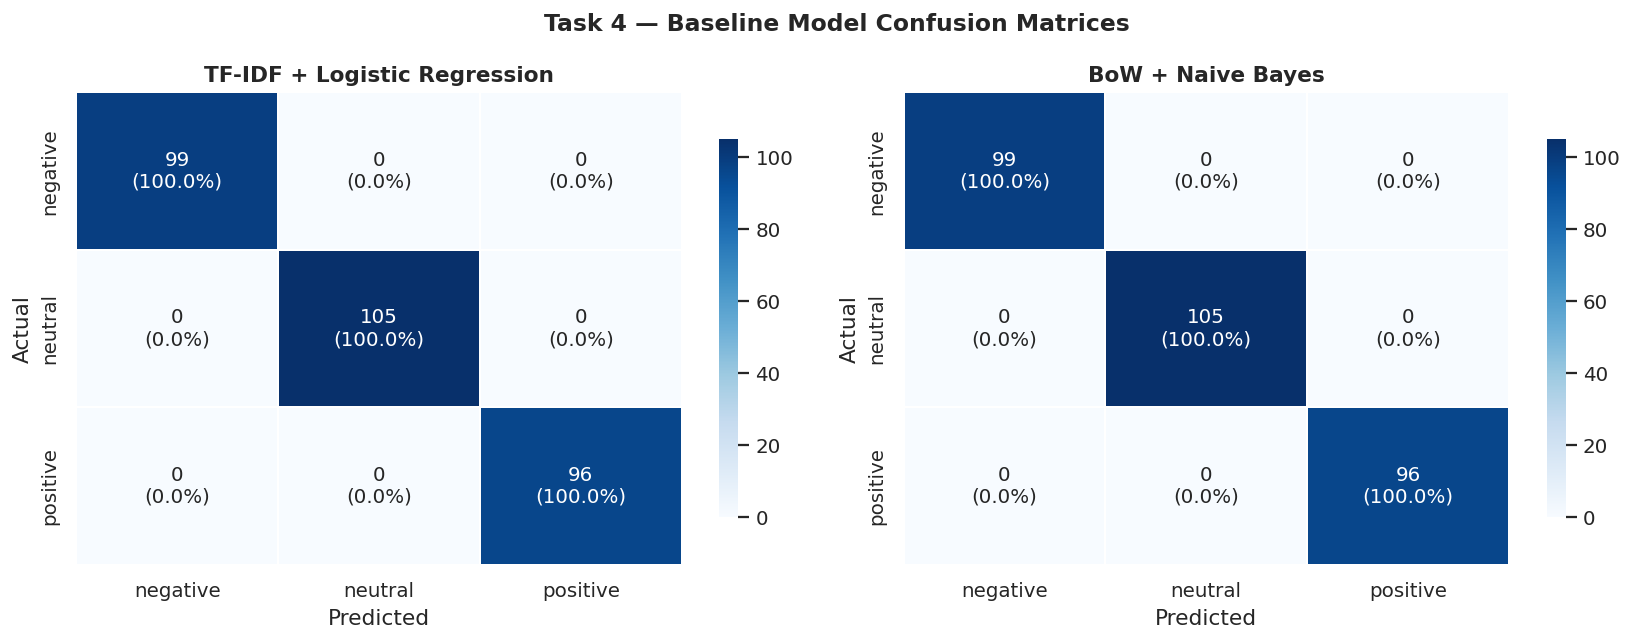

✅ Saved → results/task4_baseline_confusion.png


In [51]:
# Baseline confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Task 4 — Baseline Model Confusion Matrices', fontsize=13, fontweight='bold')

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_nb],
                              ['TF-IDF + Logistic Regression', 'BoW + Naive Bayes']):
    cm = confusion_matrix(y_te, y_pred)
    cm_p = cm.astype(float)/cm.sum(axis=1, keepdims=True)*100
    annot = np.array([[f'{v}\n({p:.1f}%)' for v,p in zip(rv,rp)]
                      for rv,rp in zip(cm, cm_p)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=1, linecolor='white', cbar_kws={'shrink':0.8})
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('results/task4_baseline_confusion.png', bbox_inches='tight')
plt.show()
print('✅ Saved → results/task4_baseline_confusion.png')


## Task 5 — Sequence Model: Bidirectional LSTM

Architecture Design

```
Input: padded integer sequence  (batch_size × 50)
         │
Embedding(8000, 64)             → (batch × 50 × 64) dense word vectors
         │
SpatialDropout1D(0.2)           → regularise embedding features
         │
Bidirectional(LSTM(64))         → reads sequence left→right AND right→left
  return_sequences=True         → (batch × 50 × 128)
         │
GlobalMaxPooling1D              → (batch × 128)  most prominent feature per dim
         │
Dense(64, ReLU) → Dropout(0.4)
         │
Dense(3, Softmax)               → probability over 3 sentiment classes

Loss     : Categorical Cross-Entropy
Optimiser: Adam (lr=0.001)
Metric   : Accuracy, Macro F1
```

In [52]:
# One-hot encode labels for categorical cross-entropy
y_tr_cat = to_categorical(y_tr, num_classes=N_CLASSES)
y_te_cat = to_categorical(y_te, num_classes=N_CLASSES)

# Build Bi-LSTM model
def build_lstm(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM,
               max_len=MAX_LEN, n_classes=N_CLASSES):
    model = Sequential(name='SentimentBiLSTM')

    # 1) Embedding: integer tokens → dense vectors
    model.add(Embedding(input_dim=vocab_size, output_dim=embed_dim,
                        input_length=max_len, name='embedding'))
    # 2) Spatial dropout on embedding features
    model.add(SpatialDropout1D(0.2, name='spatial_drop'))
    # 3) Bidirectional LSTM — reads sequence in both directions
    model.add(Bidirectional(
        LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1),
        name='bilstm'
    ))
    # 4) Global max pooling — take the most prominent feature across timesteps
    model.add(GlobalMaxPooling1D(name='global_max'))
    # 5) Dense classifier
    model.add(Dense(64, activation='relu', name='fc'))
    model.add(Dropout(0.4, name='drop_fc'))
    # 6) Softmax output
    model.add(Dense(n_classes, activation='softmax', name='output'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


tf.random.set_seed(SEED)
lstm_model = build_lstm()
lstm_model.summary()


Model: "SentimentBiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_drop (SpatialDropout1D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max (GlobalMaxPooling1D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [53]:
# Train Bi-LSTM
es = EarlyStopping(monitor='val_loss', patience=8,
                   restore_best_weights=True, verbose=1)

history_lstm = lstm_model.fit(
    X_tr_pad, y_tr_cat,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    callbacks=[es],
    verbose=1
)
print(f'Stopped at epoch {len(history_lstm.history["loss"])}')


Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - accuracy: 0.5451 - loss: 1.0729 - val_accuracy: 0.9667 - val_loss: 0.9890
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.9196 - loss: 0.6136 - val_accuracy: 1.0000 - val_loss: 0.0793
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - accuracy: 0.9971 - loss: 0.0219 - val_accuracy: 1.0000 - val_loss: 2.1031e-04
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 8.1246e-05
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 3.9497e-05
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 1.0000 - loss: 9.2321e-04 - val_accuracy: 1.0000 - val_loss: 3.0003e-05
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 1.0000 - loss: 8.6016e-04 - val_accuracy: 1.0000 - val_loss: 1.5265e-05
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 1.0000 - lo

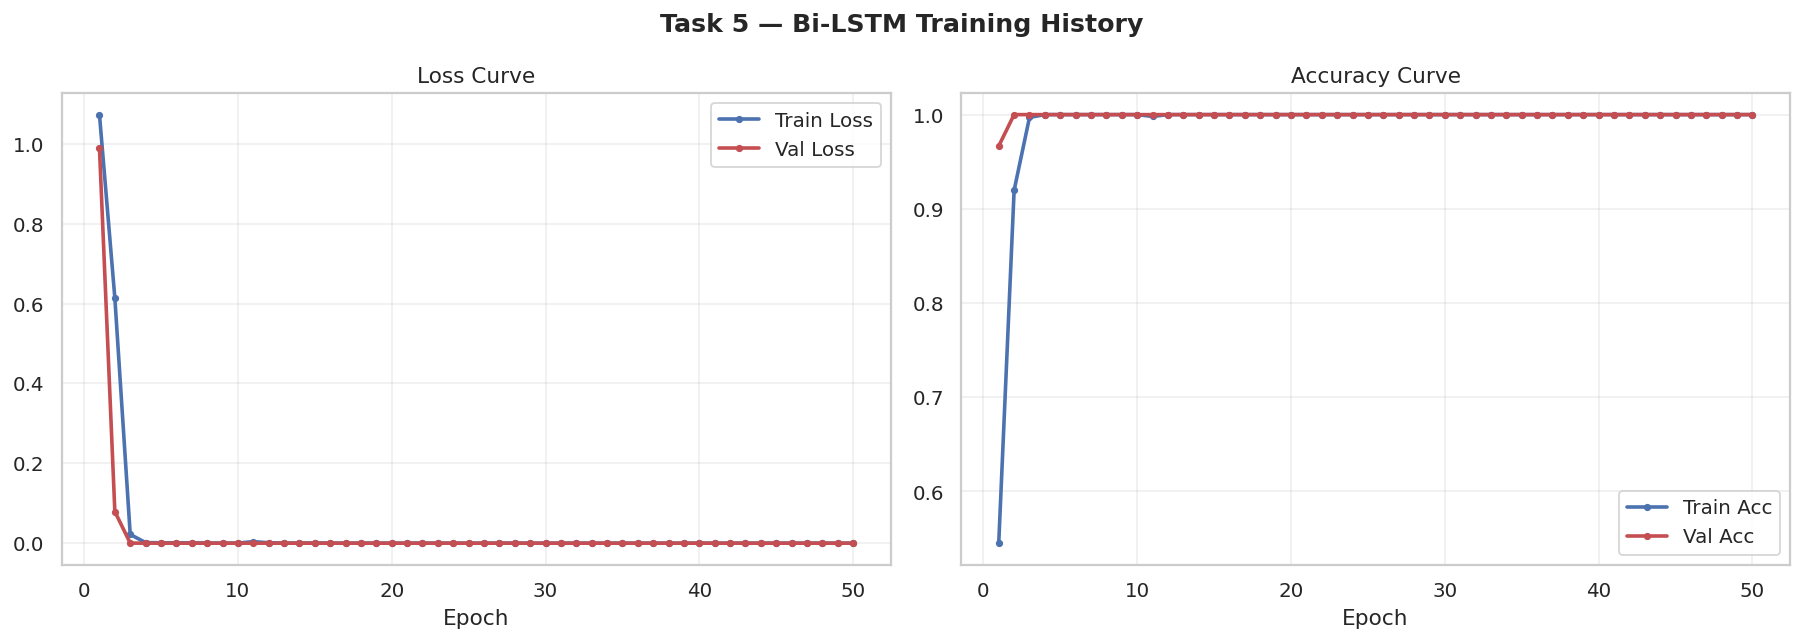

✅ Saved → results/task5_lstm_training.png


In [54]:
# LSTM training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task 5 — Bi-LSTM Training History', fontsize=14, fontweight='bold')
ep = range(1, len(history_lstm.history['loss'])+1)

axes[0].plot(ep, history_lstm.history['loss'],     'b-o', ms=3, lw=2, label='Train Loss')
axes[0].plot(ep, history_lstm.history['val_loss'], 'r-o', ms=3, lw=2, label='Val Loss')
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=.3)

axes[1].plot(ep, history_lstm.history['accuracy'],     'b-o', ms=3, lw=2, label='Train Acc')
axes[1].plot(ep, history_lstm.history['val_accuracy'], 'r-o', ms=3, lw=2, label='Val Acc')
axes[1].set_title('Accuracy Curve'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=.3)

plt.tight_layout()
plt.savefig('results/task5_lstm_training.png', bbox_inches='tight')
plt.show()
print('✅ Saved → results/task5_lstm_training.png')


In [ ]:
# Comprehensive evaluation figure (required output)
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Task 5 — Model Evaluation Summary', fontsize=14, fontweight='bold')

# (A) Baseline LR confusion matrix
cm_lr = confusion_matrix(y_te, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=1, linecolor='white')
axes[0,0].set_title('TF-IDF + LR Confusion Matrix', fontweight='bold')
axes[0,0].set_ylabel('Actual'); axes[0,0].set_xlabel('Predicted')

# (B) Bi-LSTM confusion matrix
cm_lstm = confusion_matrix(y_te, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Purples', ax=axes[0,1],
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=1, linecolor='white')
axes[0,1].set_title('Bi-LSTM Confusion Matrix', fontweight='bold')
axes[0,1].set_ylabel('Actual'); axes[0,1].set_xlabel('Predicted')

# (C) Model comparison
models = ['BoW\n+ Naive Bayes', 'TF-IDF\n+ LR', 'Bi-LSTM\n(Embeddings)']
accs   = [acc_nb, acc_lr, acc_lstm]
f1s    = [f1_nb,  f1_lr,  f1_lstm]
x = np.arange(3); w = 0.35
axes[0,2].bar(x-w/2, accs, w, label='Accuracy', color='#1E88E5', alpha=0.85)
axes[0,2].bar(x+w/2, f1s,  w, label='Macro F1', color='#43A047', alpha=0.85)
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(models)
axes[0,2].set_ylim(0, 1); axes[0,2].set_ylabel('Score')
axes[0,2].set_title('Model Comparison', fontweight='bold')
axes[0,2].legend(); axes[0,2].grid(axis='y', alpha=0.3)
for i,(a,f) in enumerate(zip(accs,f1s)):
    axes[0,2].text(i-w/2, a+0.01, f'{a:.3f}', ha='center', fontsize=9, fontweight='bold')
    axes[0,2].text(i+w/2, f+0.01, f'{f:.3f}', ha='center', fontsize=9, fontweight='bold')

# (D) LSTM training loss
ep = range(1, len(history_lstm.history['loss'])+1)
axes[1,0].plot(ep, history_lstm.history['loss'],     'b-', lw=2, label='Train')
axes[1,0].plot(ep, history_lstm.history['val_loss'], 'r-', lw=2, label='Val')
axes[1,0].set_title('Bi-LSTM Loss', fontweight='bold')
axes[1,0].legend(); axes[1,0].grid(True, alpha=.3)

# (E) LSTM training accuracy
axes[1,1].plot(ep, history_lstm.history['accuracy'],     'b-', lw=2, label='Train')
axes[1,1].plot(ep, history_lstm.history['val_accuracy'], 'r-', lw=2, label='Val')
axes[1,1].set_title('Bi-LSTM Accuracy', fontweight='bold')
axes[1,1].legend(); axes[1,1].grid(True, alpha=.3)

# (F) Per-class F1 comparison
from sklearn.metrics import f1_score as f1s_fn
per_cls_lr   = f1s_fn(y_te, y_pred_lr,   average=None, labels=[0,1,2])
per_cls_lstm = f1s_fn(y_te, y_pred_lstm, average=None, labels=[0,1,2])
x2 = np.arange(N_CLASSES)
axes[1,2].bar(x2-0.2, per_cls_lr,   0.35, label='TF-IDF+LR',  color='#1E88E5', alpha=0.85)
axes[1,2].bar(x2+0.2, per_cls_lstm, 0.35, label='Bi-LSTM',     color='#8E24AA', alpha=0.85)
axes[1,2].set_xticks(x2); axes[1,2].set_xticklabels(le.classes_)
axes[1,2].set_ylim(0,1); axes[1,2].set_ylabel('F1-Score')
axes[1,2].set_title('Per-Class F1 Comparison', fontweight='bold')
axes[1,2].legend(); axes[1,2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/model_evaluation.png', bbox_inches='tight')
plt.show()
print('✅ Saved → results/model_evaluation.png')


In [56]:
# Sample predictions (saved as text file)
LABEL_MAP = {i: cls for i, cls in enumerate(le.classes_)}

def predict_sentiment(text):
    clean  = preprocess_text(text)
    seq    = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs  = lstm_model.predict(padded, verbose=0)[0]
    pred   = LABEL_MAP[probs.argmax()]
    conf   = probs.max()
    return pred, conf, probs

test_messages = [
    "I am absolutely delighted with the service! Everything was handled perfectly.",
    "My refund has been pending for 3 weeks. This is completely unacceptable.",
    "I need information about my account billing cycle.",
    "Great support team, very quick to respond. Highly recommend!",
    "The app keeps crashing and nobody is helping me fix it.",
    "Please let me know the status of my request.",
    "Worst experience ever. I am cancelling my subscription immediately.",
    "Thank you for resolving my issue so quickly!",
    "How do I update my payment method on the portal?",
    "I have been waiting 5 days for a response. Extremely frustrated."
]

lines = ['=' * 70,
         'SAMPLE PREDICTIONS — Bi-LSTM Sentiment Classifier',
         '=' * 70]

for msg in test_messages:
    pred, conf, probs = predict_sentiment(msg)
    lines.append(f'\nInput     : {msg}')
    lines.append(f'Prediction: {pred.upper()} ({conf:.1%} confidence)')
    lines.append(f'Scores    : negative={probs[0]:.3f}  neutral={probs[1]:.3f}  positive={probs[2]:.3f}')

output_text = '\n'.join(lines)
print(output_text)

with open('results/sample_predictions.txt', 'w') as f:
    f.write(output_text)
print('\n✅ Saved → results/sample_predictions.txt')


SAMPLE PREDICTIONS — Bi-LSTM Sentiment Classifier

Input     : I am absolutely delighted with the service! Everything was handled perfectly.
Prediction: POSITIVE (100.0% confidence)
Scores    : negative=0.000  neutral=0.000  positive=1.000

Input     : My refund has been pending for 3 weeks. This is completely unacceptable.
Prediction: NEGATIVE (100.0% confidence)
Scores    : negative=1.000  neutral=0.000  positive=0.000

Input     : I need information about my account billing cycle.
Prediction: NEUTRAL (100.0% confidence)
Scores    : negative=0.000  neutral=1.000  positive=0.000

Input     : Great support team, very quick to respond. Highly recommend!
Prediction: POSITIVE (100.0% confidence)
Scores    : negative=0.000  neutral=0.000  positive=1.000

Input     : The app keeps crashing and nobody is helping me fix it.
Prediction: NEGATIVE (100.0% confidence)
Scores    : negative=1.000  neutral=0.000  positive=0.000

Input     : Please let me know the status of my request.
Prediction: NE

---
## 💬 Task 6 — Attention and Transformer Reflection

### Why do RNNs struggle with long-term dependencies?
A vanilla RNN processes tokens one at a time, updating a hidden state vector `h_t`. Information from early tokens is compressed into this vector and passed forward through every subsequent step. With long sequences, the gradient signal must travel through many time steps during backpropagation. At each step, it is multiplied by the recurrent weight matrix — if any singular value is < 1, the gradient **vanishes** (becomes ≈ 0). The model therefore cannot learn dependencies between tokens far apart in the sequence (e.g., "I was **not** happy with the resolution" — the negation at position 4 must negate "happy" at position 8).

### How do LSTMs help with memory?
LSTMs introduce a dedicated **cell state** `C_t` — a "conveyor belt" that runs through the entire sequence with only minor, gated modifications. Three gates control information flow:
- **Forget gate** `f_t = σ(W_f·[h_{t-1}, x_t] + b_f)` — decides what to discard from cell state
- **Input gate** `i_t` — decides what new information to write to cell state
- **Output gate** `o_t` — decides what to read from cell state to produce `h_t`

Because `C_t` can flow unchanged when forget gate ≈ 1, gradients propagate through long sequences without vanishing.

### What does Attention solve in sequence-to-sequence tasks?
In encoder-decoder models (e.g., translation), the encoder compresses the full source sentence into one fixed vector — a bottleneck that loses information for long sentences. **Attention** instead produces a *dynamic context vector* for each output token by computing a weighted sum of all encoder hidden states. The model learns to **attend to** the most relevant source tokens for each output step — e.g., when generating the word "nicht" (German negation), the decoder attends strongly to "not" in the English source.

### Why are Transformers important in modern NLP and Generative AI?
The **Transformer** (Vaswani et al., 2017) replaces recurrence entirely with **Multi-Head Self-Attention**:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

| Property | RNN/LSTM | Transformer |
|---|---|---|
| Parallelism | Sequential — must wait for `h_{t-1}` | Fully parallel across all tokens |
| Long-range dependency | Decays with distance | O(1) — direct attention to any token |
| Training speed | Slow on long sequences | Much faster on modern GPUs |
| Pre-training at scale | Difficult | BERT, GPT-4, Llama-3 — billions of parameters |

Transformers form the backbone of **all modern NLP systems** — BERT (understanding), GPT (generation), T5 (text-to-text), Whisper (speech), DALL·E (image generation) — and have extended to computer vision (ViT) and protein folding (AlphaFold).
